In [51]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [52]:
from __future__ import annotations

import os

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rc
from scipy.io import readsav

from mhsxtrapy._boundary import BoundaryData
from mhsxtrapy._field import extrapolate
from mhsxtrapy.atmosphere import (
    bdensity_linear,
    bdensity_tanh,
    bpressure_linear,
    bpressure_tanh,
    btemp_linear,
    btemp_tanh,
    fdensity_linear,
    fdensity_tanh,
    fpressure_linear,
    fpressure_tanh,
)
from mhsxtrapy.constants import (
    G_SOLAR,
    MU0,
    T_CORONA,
    T_PHOTOSPHERE,
    Z_CORONA,
    Z_PHOTOSPHERE,
    L,
)
from mhsxtrapy.plotting import plot_magnetogram
from mhsxtrapy.types import WhichSolution

rc("font", **{"family": "serif", "serif": ["Times"]})
rc("text", usetex=True)
plt.rcParams["text.usetex"] = False

#### Two examples for 1D background atmospheres (temperature, pressure, density)

##### Load data from file

--------------------------------------------------
Date: Tue Sep  6 15:16:46 2022
User: xszhu
Host: HR30
--------------------------------------------------
Format: 9
Architecture: x86_64
Operating System: linux
IDL Version: 7.1.1
--------------------------------------------------
Successfully read 33 records of which:
 - 29 are of type VARIABLE
 - 1 are of type NOTICE
 - 1 are of type VERSION
 - 1 are of type TIMESTAMP
--------------------------------------------------
Available variables:
 - b2dx1 [<class 'numpy.ndarray'>]
 - b2dy1 [<class 'numpy.ndarray'>]
 - b2dz1 [<class 'numpy.ndarray'>]
 - d2d1 [<class 'numpy.ndarray'>]
 - b2dx2 [<class 'numpy.ndarray'>]
 - b2dy2 [<class 'numpy.ndarray'>]
 - b2dz2 [<class 'numpy.ndarray'>]
 - d2d2 [<class 'numpy.ndarray'>]
 - b2dx3 [<class 'numpy.ndarray'>]
 - b2dy3 [<class 'numpy.ndarray'>]
 - b2dz3 [<class 'numpy.ndarray'>]
 - d2d3 [<class 'numpy.ndarray'>]
 - b2dx4 [<class 'numpy.ndarray'>]
 - b2dy4 [<class 'numpy.ndarray'>]
 - b2dz4 [<class '

/var/folders/_n/bcpnhg552nz0sk_18sb4m33r0000gn/T/ipykernel_17768/2037855336.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


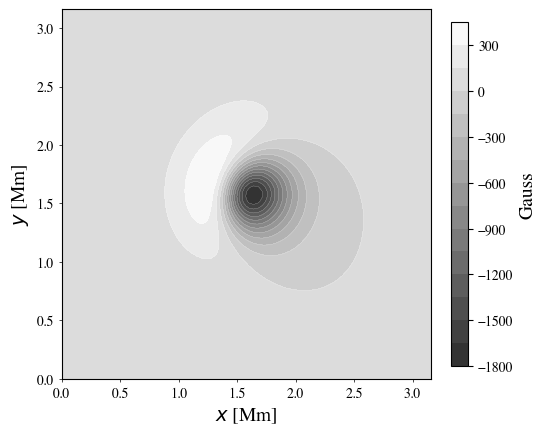

In [53]:
path = "../data/Analytic_boundary_data.sav"
data = readsav(path, python_dict=True, verbose=True)

data_bz = data[
    "b2dz5"
]  # Read magnetic field data in Gauss, see "Info Array" and "Info Unit" above.
data_bx = data["b2dx5"]
data_by = data["b2dy5"]

nz = 50

pixel_size = 40.0 * 10**-3
pz = 40.0 * 10**-3

data2d = BoundaryData.from_array(data_bz, pixel_size, nz, pz)

fig, ax = plot_magnetogram(data2d)
fig.show()

##### Extrapolate magentic field

In [54]:
result = extrapolate(
    data2d,
    alpha=-3.0 / ((data2d.nx - 1) * data2d.px),
    a=0.15,
    which_solution=WhichSolution.NADOL_NEUKIRCH,
    b=1.0,
    z0=2.0,
    deltaz=0.2,
)

##### Background atmospere model 1

In [55]:
btemp = btemp_tanh(result)
bpressure = bpressure_tanh(result)
bdensity = bdensity_tanh(result)

fpressure = fpressure_tanh(result)
fdensity = fdensity_tanh(result)

current_density = result.j3d
lorentz_force = result.lf3d

##### Background atmosphere model 2

In [56]:
temps = np.array([T_PHOTOSPHERE, 5200.0, T_CORONA])  # Kelvin
heights = np.array([Z_PHOTOSPHERE, 2.0, Z_CORONA])  # Mm

btemp_lin = btemp_linear(result, heights, temps)
bpressure_lin = bpressure_linear(result, heights, temps)
bdensity_lin = bdensity_linear(result, heights, temps)

fpressure_lin = fpressure_linear(result, heights, temps)
fdensity_lin = fdensity_linear(result, heights, temps)

##### Atmospheric parameters

In [57]:
z_arr = result.z
z0 = result.z0
B0 = result.B0
PB0 = result.PB0
BETA0 = result.BETA0

##### Temperature [Kelvin]

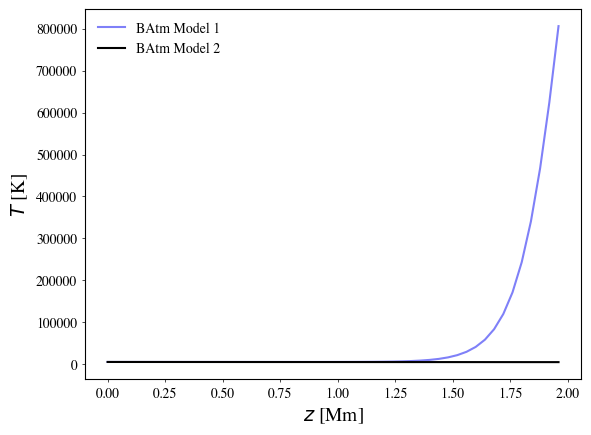

In [58]:
fig, ax = plt.subplots()

ax.plot(
    z_arr,
    btemp,
    linewidth=1.5,
    color=(0.498, 0.502, 0.973),
    label=r"BAtm Model 1",
)

ax.plot(
    z_arr,
    btemp_lin,
    linewidth=1.5,
    color="black",
    label=r"BAtm Model 2",
)

ax.set_xlabel(r"$z$ [Mm]", size=14)
plt.legend(frameon=False)
ax.tick_params(direction="out", length=2, width=0.5)
ax.set_ylabel(r"$T$ [K]", size=14)

plt.show()

##### Pressure [normlised on photosphere] 

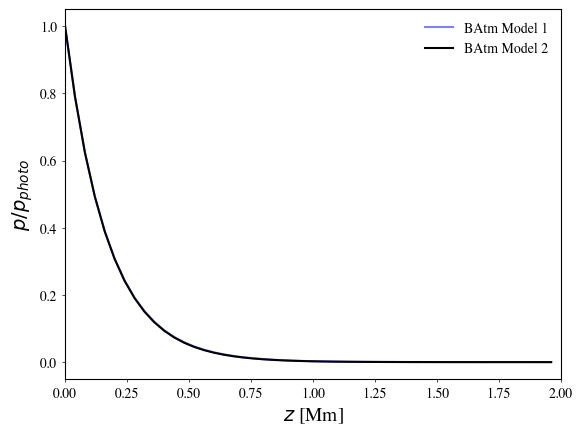

In [59]:
fig, ax = plt.subplots()

ax.plot(
    z_arr,
    bpressure,
    linewidth=1.5,
    color=(0.498, 0.502, 0.973),
    label=r"BAtm Model 1",
)

ax.plot(
    z_arr,
    bpressure_lin,
    linewidth=1.5,
    color="black",
    label=r"BAtm Model 2",
)

ax.set_xlabel(r"$z$ [Mm]", size=14)
plt.legend(frameon=False)
ax.tick_params(direction="out", length=2, width=0.5)
ax.set_xlim([0, z0])
ax.set_ylabel(r"$p/p_{photo}$", size=14)

plt.show()

##### Pressure [$\text{kg}$ $\text{s}^{-2}$ $\text{m}^{-1}$]

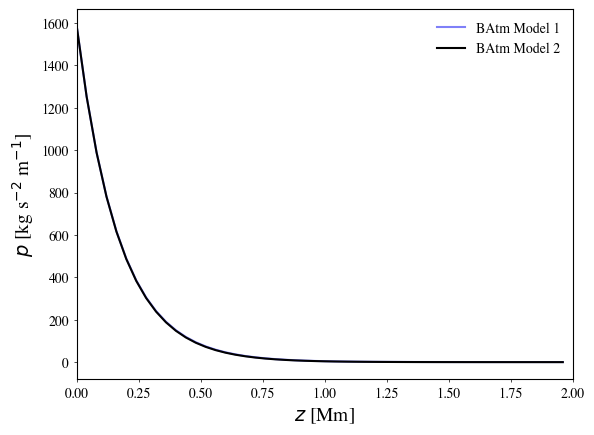

In [60]:
fig, ax = plt.subplots()

ax.plot(
    z_arr,
    bpressure * (B0 * 10**-4) ** 2.0 / MU0,
    linewidth=1.5,
    color=(0.498, 0.502, 0.973),
    label=r"BAtm Model 1",
)

ax.plot(
    z_arr,
    bpressure_lin * (B0 * 10**-4) ** 2.0 / MU0,
    linewidth=1.5,
    color="black",
    label=r"BAtm Model 2",
)

ax.set_xlabel(r"$z$ [Mm]", size=14)
plt.legend(frameon=False)
ax.tick_params(direction="out", length=2, width=0.5)
ax.set_xlim([0, data3d.z0])  # type: ignore
ax.set_ylabel(r"$p$ [kg s$^{-2}$ m$^{-1}$]", size=14)

plt.show()

##### Density [normlised on photosphere]

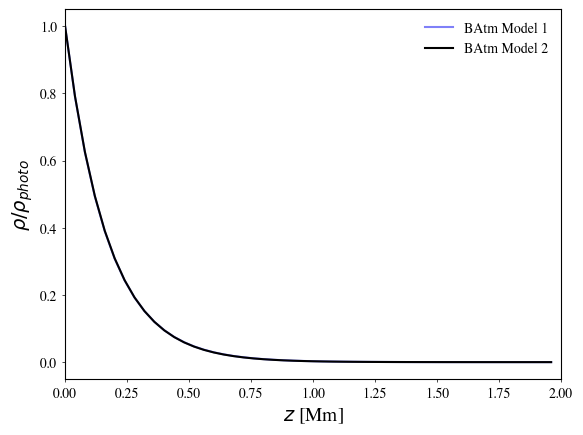

In [61]:
fig, ax = plt.subplots()

ax.plot(
    z_arr,
    bdensity,
    linewidth=1.5,
    color=(0.498, 0.502, 0.973),
    label=r"BAtm Model 1",
)

ax.plot(
    z_arr,
    bdensity_lin,
    linewidth=1.5,
    color="black",
    label=r"BAtm Model 2",
)

ax.set_xlabel(r"$z$ [Mm]", size=14)
plt.legend(frameon=False)
ax.tick_params(direction="out", length=2, width=0.5)
ax.set_xlim([0, data3d.z0])  # type: ignore
ax.set_ylabel(r"$\rho / \rho_{photo}$", size=14)

plt.show()

##### Density [$\text{kg}$ $\text{m}^{-3}$]

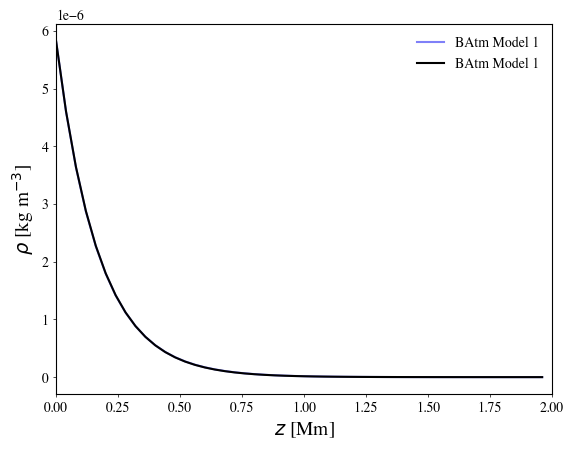

In [62]:
fig, ax = plt.subplots()

ax.plot(
    z_arr,
    bdensity * (B0 * 10**-4) ** 2.0 / (MU0 * G_SOLAR * L),
    linewidth=1.5,
    color=(0.498, 0.502, 0.973),
    label=r"BAtm Model 1",
)

ax.plot(
    z_arr,
    bdensity_lin * (B0 * 10**-4) ** 2.0 / (MU0 * G_SOLAR * L),
    linewidth=1.5,
    color="black",
    label=r"BAtm Model 1",
)

ax.set_xlabel(r"$z$ [Mm]", size=14)
plt.legend(frameon=False)
ax.tick_params(direction="out", length=2, width=0.5)
ax.set_xlim([0, data3d.z0])  # type: ignore
ax.set_ylabel(r"$\rho$ [kg m$^{-3}$]", size=14)

plt.show()

##### Find x and y location of maximal photospheric $B_z$

In [63]:
iy_max, ix_max = np.unravel_index(np.argmax(data2d.bz), data2d.bz.shape)

##### Current density at ix_max, iy_max [$\text{A}$ $\text{m}^{-2}$]

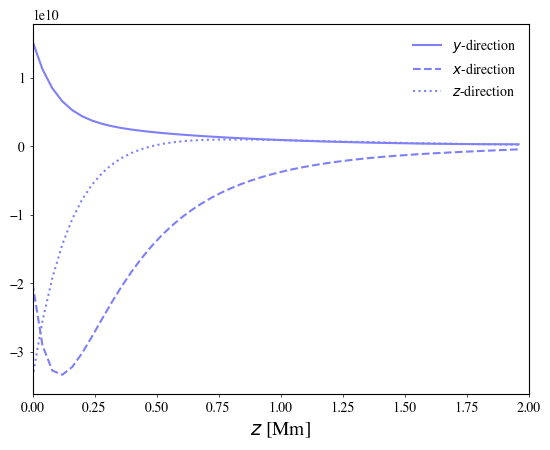

In [64]:
fig, ax = plt.subplots()

ax.plot(
    z_arr,
    current_density[iy_max, ix_max, :, 0],
    linewidth=1.5,
    label=r"$y$-direction",
    color=(0.498, 0.502, 0.973),
    linestyle="solid",
)
ax.plot(
    z_arr,
    current_density[iy_max, ix_max, :, 1],
    linewidth=1.5,
    label=r"$x$-direction",
    color=(0.498, 0.502, 0.973),
    linestyle="dashed",
)
ax.plot(
    z_arr,
    current_density[iy_max, ix_max, :, 2],
    linewidth=1.5,
    label=r"$z$-direction",
    color=(0.498, 0.502, 0.973),
    linestyle="dotted",
)

ax.set_xlabel(r"$z$ [Mm]", size=14)
plt.legend(frameon=False)
ax.tick_params(direction="out", length=2, width=0.5)
ax.set_xlim([0, z0])

plt.show()

##### Lorentz force at ix_max, iy_max [$\text{kg}$ $\text{s}^{-1} \text{m}^{-2}$]

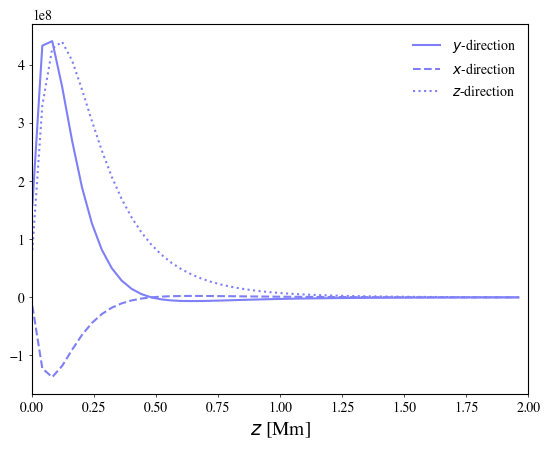

In [65]:
fig, ax = plt.subplots()

ax.plot(
    z_arr,
    lorentz_force[iy_max, ix_max, :, 0],
    linewidth=1.5,
    label=r"$y$-direction",
    color=(0.498, 0.502, 0.973),
    linestyle="solid",
)
ax.plot(
    z_arr,
    lorentz_force[iy_max, ix_max, :, 1],
    linewidth=1.5,
    label=r"$x$-direction",
    color=(0.498, 0.502, 0.973),
    linestyle="dashed",
)
ax.plot(
    z_arr,
    lorentz_force[iy_max, ix_max, :, 2],
    linewidth=1.5,
    label=r"$z$-direction",
    color=(0.498, 0.502, 0.973),
    linestyle="dotted",
)

ax.set_xlabel(r"$z$ [Mm]", size=14)
plt.legend(frameon=False)
ax.tick_params(direction="out", length=2, width=0.5)
ax.set_xlim([0, z0])
plt.show()